## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [3]:
data = pd.read_csv("Cleaned_data.csv")
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


## 📊 1. Create Month Column

In [4]:
# Convert DATE to datetime
data["DATE"] = pd.to_datetime(data["DATE"])

# Create YearMonth column
data["YEARMONTH"] = data["DATE"].dt.to_period("M")

data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget,2018-08


## 2. Create Monthly Store Metrics

In [5]:
store_monthly = data.groupby(["STORE_NBR", "YEARMONTH"]).agg({
    "TOT_SALES":"sum",
    "LYLTY_CARD_NBR":"nunique",
    "TXN_ID":"nunique",
    "PROD_QTY":"sum"
}).reset_index()

store_monthly.rename(columns={
    "LYLTY_CARD_NBR":"CUSTOMERS",
    "TXN_ID":"TRANSACTIONS"
}, inplace=True)

store_monthly.head()

,STORE_NBR,YEARMONTH,TOT_SALES,CUSTOMERS,TRANSACTIONS,PROD_QTY
0,1,2018-07,188.9,47,49,58
1,1,2018-08,168.4,41,41,52
2,1,2018-09,268.1,57,59,71
3,1,2018-10,175.4,39,40,51
4,1,2018-11,184.8,44,45,55


## 3. Create Additional Metrics

In [6]:
# Average Transaction Value
store_monthly["AVG_TRANS_VALUE"] = store_monthly["TOT_SALES"] / store_monthly["TRANSACTIONS"]

# Units Per Transaction
store_monthly["UNITS_PER_TRANS"] = store_monthly["PROD_QTY"] / store_monthly["TRANSACTIONS"]

# Price per Unit
store_monthly["PRICE_PER_UNIT"] = store_monthly["TOT_SALES"] / store_monthly["PROD_QTY"]

store_monthly.head()


,STORE_NBR,YEARMONTH,TOT_SALES,CUSTOMERS,TRANSACTIONS,PROD_QTY,AVG_TRANS_VALUE,UNITS_PER_TRANS,PRICE_PER_UNIT
0,1,2018-07,188.9,47,49,58,3.855102,1.183673,3.256897
1,1,2018-08,168.4,41,41,52,4.107317,1.268293,3.238462
2,1,2018-09,268.1,57,59,71,4.544068,1.203390,3.776056
3,1,2018-10,175.4,39,40,51,4.385000,1.275000,3.439216
4,1,2018-11,184.8,44,45,55,4.106667,1.222222,3.360000


## 4. Identify Trial Stores

In [7]:
trial_stores = [77, 86, 88]

store_monthly[store_monthly["STORE_NBR"].isin(trial_stores)].head(50)

,STORE_NBR,YEARMONTH,TOT_SALES,CUSTOMERS,TRANSACTIONS,PROD_QTY,AVG_TRANS_VALUE,UNITS_PER_TRANS,PRICE_PER_UNIT
880,77,2018-07,268.40,47,51,77,5.262745,1.509804,3.485714
881,77,2018-08,247.50,46,46,71,5.380435,1.543478,3.485915
882,77,2018-09,216.80,40,42,66,5.161905,1.571429,3.284848
883,77,2018-10,194.30,36,37,50,5.251351,1.351351,3.886000
884,77,2018-11,224.90,39,42,63,5.354762,1.500000,3.569841
885,77,2018-12,255.20,43,44,67,5.800000,1.522727,3.808955
886,77,2019-01,188.40,31,35,58,5.382857,1.657143,3.248276
887,77,2019-02,211.60,40,40,67,5.290000,1.675000,3.158209
888,77,2019-03,255.10,46,51,76,5.001961,1.490196,3.356579
889,77,2019-04,258.10,47,47,76,5.491489,1.617021,3.396053


## 5. Filter Pre-Trial Data

In [8]:
pre_trial = store_monthly[store_monthly["YEARMONTH"] < "2019-02"]

pre_trial.head()

,STORE_NBR,YEARMONTH,TOT_SALES,CUSTOMERS,TRANSACTIONS,PROD_QTY,AVG_TRANS_VALUE,UNITS_PER_TRANS,PRICE_PER_UNIT
0,1,2018-07,188.9,47,49,58,3.855102,1.183673,3.256897
1,1,2018-08,168.4,41,41,52,4.107317,1.268293,3.238462
2,1,2018-09,268.1,57,59,71,4.544068,1.203390,3.776056
3,1,2018-10,175.4,39,40,51,4.385000,1.275000,3.439216
4,1,2018-11,184.8,44,45,55,4.106667,1.222222,3.360000


## 6. Visualise Store Sales

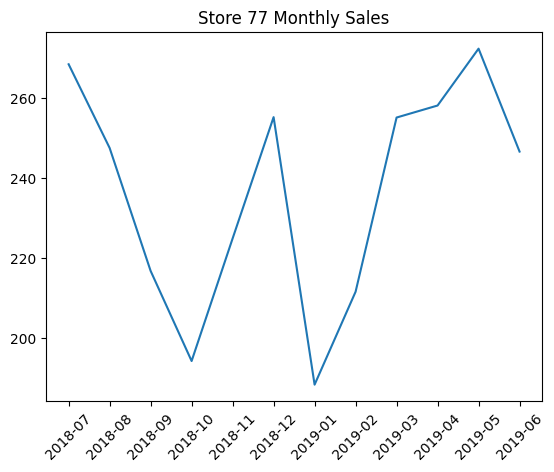

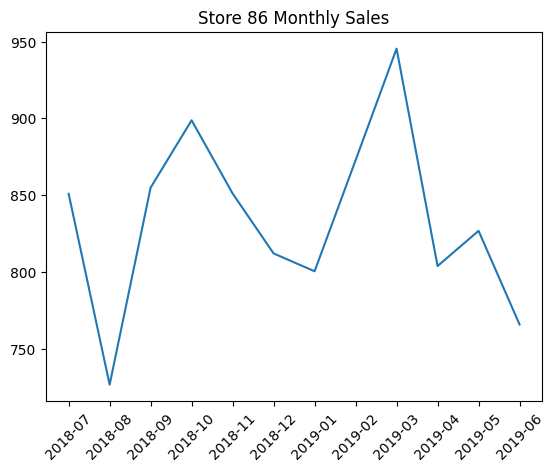

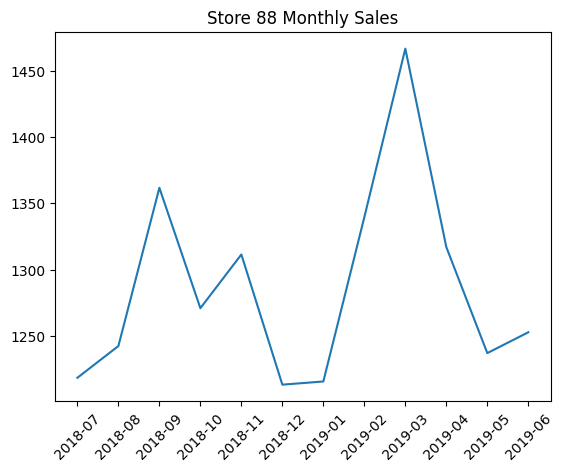

In [9]:

for store in trial_stores:
    trial_data = store_monthly[store_monthly["STORE_NBR"] == store]

    plt.figure()
    plt.plot(trial_data["YEARMONTH"].astype(str), trial_data["TOT_SALES"])
    plt.title(f"Store {store} Monthly Sales")
    plt.xticks(rotation=45)
    plt.show()

## 7. Create Pivot Table

In [10]:
sales_pivot = store_monthly.pivot(index="YEARMONTH",
                                  columns="STORE_NBR",
                                  values="TOT_SALES")

sales_pivot.head()

STORE_NBR,1,2,3,4,5,6,7,8,9,10,...,263,264,265,266,267,268,269,270,271,272
YEARMONTH,,,,,,,,,,,,,,,,,,,,,
2018-07,188.9,140.5,1164.90,1318.3,763.8,241.9,1004.3,361.2,271.1,829.20,...,33.5,209.4,239.7,124.7,6.2,213.50,929.8,883.60,871.0,392.30
2018-08,168.4,180.9,998.15,1188.1,654.5,177.6,1058.7,362.6,323.4,857.75,...,26.5,187.8,204.8,135.0,24.9,291.95,801.3,943.15,613.7,326.95
2018-09,268.1,133.9,1011.30,1168.0,875.2,192.2,1096.3,282.8,340.5,888.00,...,21.8,181.0,126.9,133.4,20.6,158.90,844.0,780.20,721.4,294.50
2018-10,175.4,160.1,1017.50,1275.0,740.6,268.9,972.1,412.6,330.9,812.00,...,31.4,167.4,155.2,162.7,14.4,229.90,1044.2,736.40,725.6,405.10
2018-11,184.8,143.3,936.60,1089.6,707.0,244.7,1025.5,328.8,346.3,787.80,...,15.8,175.3,276.1,124.7,40.3,202.90,882.0,874.20,807.0,355.80


## 8. Find Control Store (Correlation)

In [11]:
# Clean Pivot
sales_pivot = sales_pivot.dropna(axis=1)

In [12]:
# Correlation
corr_77 = sales_pivot.corrwith(sales_pivot[77])

In [13]:
# Sort
corr_77 = corr_77.sort_values(ascending=False)

In [14]:
# Remove itself
corr_77 = corr_77[corr_77.index != 77]

corr_77.head()

STORE_NBR
35     0.782175
167    0.698594
157    0.677769
53     0.665977
234    0.643556
dtype: float64

In [15]:
# Correlation for 86
corr_86 = sales_pivot.corrwith(sales_pivot[86]).sort_values(ascending=False)
corr_86 = corr_86[corr_86.index != 86]

corr_88 = sales_pivot.corrwith(sales_pivot[88]).sort_values(ascending=False)
corr_88 = corr_88[corr_88.index != 88]

print("Correlation of 86:", corr_86.head())
print("Correlation for 88:", corr_88.head())

Correlation of 86: STORE_NBR
231    0.798394
88     0.662429
260    0.651753
109    0.625435
229    0.597418
dtype: float64
Correlation for 88: STORE_NBR
159    0.839369
86     0.662429
229    0.662335
243    0.626704
201    0.604780
dtype: float64


## 9. Visualization

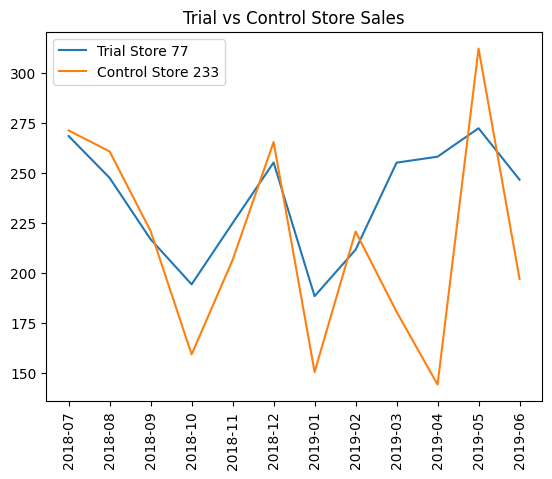

In [16]:
trial = store_monthly[store_monthly["STORE_NBR"] == 77]
control = store_monthly[store_monthly["STORE_NBR"] == 233]

plt.figure()
plt.plot(trial["YEARMONTH"].astype(str), trial["TOT_SALES"], label="Trial Store 77")
plt.plot(control["YEARMONTH"].astype(str), control["TOT_SALES"], label="Control Store 233")

plt.xticks(rotation=90)
plt.legend()
plt.title("Trial vs Control Store Sales")
plt.show()

## 10. Define Trial Period

In [17]:
trial_period = store_monthly[store_monthly["YEARMONTH"] >= "2019-02"]
pre_trial = store_monthly[store_monthly["YEARMONTH"] <= "2019-02"]

###   Compare Trial vs Control

In [18]:
trial_77 = trial_period[trial_period["STORE_NBR"] == 77]
control_35 = trial_period[trial_period["STORE_NBR"] == 35]

## 11. Calculate % Differnce (STORE_77)

In [19]:
comparison_77 = trial_77.merge(control_35, on="YEARMONTH", suffixes=("_trial", "_control"))

comparison_77["PERCENT_DIFF"] = (
    (comparison_77["TOT_SALES_trial"] - comparison_77["TOT_SALES_control"])
    / comparison_77["TOT_SALES_control"]
) * 100

comparison_77

,STORE_NBR_trial,YEARMONTH,TOT_SALES_trial,CUSTOMERS_trial,TRANSACTIONS_trial,PROD_QTY_trial,AVG_TRANS_VALUE_trial,UNITS_PER_TRANS_trial,PRICE_PER_UNIT_trial,STORE_NBR_control,TOT_SALES_control,CUSTOMERS_control,TRANSACTIONS_control,PROD_QTY_control,AVG_TRANS_VALUE_control,UNITS_PER_TRANS_control,PRICE_PER_UNIT_control,PERCENT_DIFF
0,77,2019-02,211.6,40,40,67,5.290000,1.675000,3.158209,35,111.9,30,30,32,3.730000,1.066667,3.496875,89.097408
1,77,2019-03,255.1,46,51,76,5.001961,1.490196,3.356579,35,124.1,31,32,36,3.878125,1.125000,3.447222,105.560032
2,77,2019-04,258.1,47,47,76,5.491489,1.617021,3.396053,35,143.6,37,40,41,3.590000,1.025000,3.502439,79.735376
3,77,2019-05,272.3,53,54,78,5.042593,1.444444,3.491026,35,154.1,34,37,45,4.164865,1.216216,3.424444,76.703439
4,77,2019-06,246.6,38,39,65,6.323077,1.666667,3.793846,35,124.0,28,30,32,4.133333,1.066667,3.875000,98.870968


In [20]:
comparison_77["PERCENT_DIFF"].mean()

89.99344474880914

## Store 86

In [21]:
trial_86 = trial_period[trial_period["STORE_NBR"] == 86]
control_231 = trial_period[trial_period["STORE_NBR"] == 231]

comparison_86 = trial_86.merge(control_231, on="YEARMONTH", suffixes=("_trial","_control"))

comparison_86["PERCENT_DIFF"] = (
    (comparison_86["TOT_SALES_trial"] - comparison_86["TOT_SALES_control"]) 
    / comparison_86["TOT_SALES_control"]
) * 100

comparison_86["PERCENT_DIFF"].mean()

-16.175354320009593

## Store 88

In [22]:
trial_88 = trial_period[trial_period["STORE_NBR"] == 88]
control_159 = trial_period[trial_period["STORE_NBR"] == 159]

comparison_88 = trial_88.merge(control_159, on="YEARMONTH", suffixes=("_trial","_control"))

comparison_88["PERCENT_DIFF"] = (
    (comparison_88["TOT_SALES_trial"] - comparison_88["TOT_SALES_control"]) 
    / comparison_88["TOT_SALES_control"]
) * 100

comparison_88["PERCENT_DIFF"].mean()

5254.433399389167

In [23]:
# Store 88 corrected calculation
trial_mean_88 = trial_88["TOT_SALES"].mean()
control_mean_88 = control_159["TOT_SALES"].mean()

percent_diff_88 = ((trial_mean_88 - control_mean_88) / control_mean_88) * 100

percent_diff_88

4460.724137931035

In [24]:
# Store 88 corrected calculation
trial_mean_86 = trial_86["TOT_SALES"].mean()
control_mean_86 = control_231["TOT_SALES"].mean()

percent_diff_86 = ((trial_mean_86 - control_mean_86) / control_mean_86) * 100

percent_diff_86

-16.3139294790343

Note: Percentage difference is very high due to low baseline sales of control store.
Hence, this metric may not be reliable for interpretation.

In [25]:
trial_mean_88

1322.6100000000001

In [26]:
control_mean_88

29.0

In [27]:
# Absolute Difference
abs_diff_88 = trial_mean_88 - control_mean_88
abs_diff_88

1293.6100000000001

In [28]:
data.to_csv("final_data.csv", index=False)

## 🟢 Store 77 - Succesfull Trial

Store 77 shows a strong positive uplift in total sales compared to its control store.
The sales trend closely aligns pre-trial and significantly increases during the trial period.

This indicates that the new store layout had a positive impact on customer purchasing behavior.

## 🔴 Store 86 — Unsuccessful Trial

Store 86 shows a decline in total sales compared to its control store during the trial period.

Despite having similar historical patterns, the trial did not generate additional sales,
indicating that the new layout was not effective for this store.

## ⚠️ Store 88 — Inconclusive / Misleading

Store 88 shows a very large increase in sales compared to its control store.
However, the control store has significantly lower baseline sales,
which inflates the percentage difference.

Therefore, the comparison is not reliable and should be interpreted with caution.

## 🧠 Key Analytical Insight

While correlation was used to select control stores based on similar sales patterns,
it does not guarantee similarity in sales magnitude.

This led to a mismatch in Store 88, where the control store had much lower sales,
resulting in misleading percentage comparisons.

## 📈 Drivers of Change

The increase in sales (Store 77) is likely driven by:
- Higher number of customers
- Improved purchasing behavior
- Better store layout influencing buying decisions

The increase in sales (Store 77) is likely driven by:
- Higher number of customers
- Improved purchasing behavior
- Better store layout influencing buying decisions

## 🚀 FINAL RECOMMENDATIONS

1. Roll out the new store layout in stores similar to Store 77.

2. Do not implement the layout in stores similar to Store 86 without further investigation.

3. Re-evaluate control store selection for Store 88 using both correlation and sales magnitude.

4. Use additional metrics (e.g., customer count, transactions per customer) for more robust analysis.

The trial was successful in Store 77, unsuccessful in Store 86, and inconclusive in Store 88 due to an unsuitable control store.